# Predicción de cancelación de tarjeta de crédito (Churn) — Regresión Logística

**Objetivo:** desarrollar una solución analítica predictiva que permita identificar de manera anticipada a los clientes con alta probabilidad de cancelar su tarjeta de crédito, facilitando al área comercial la ejecución de campañas de retención proactivas.

**Dataset:** `BankChurners_preparado.csv` — ya se encuentra preparado (variables categóricas codificadas con one-hot encoding) y normalizado (variables numéricas estandarizadas).

**Variable objetivo:** `Attrition_Flag`. Se asume la codificación estándar del dataset original: `0 = Cliente activo (Existing Customer)` y `1 = Cliente que canceló (Attrited Customer)`. Si en tu preparación la codificación fue inversa, ajusta la interpretación de las métricas (especialmente precisión/recall de la clase positiva) más abajo.

**Contenido del cuaderno:**
1. Carga de datos
2. Exploración rápida y balance de clases
3. Separación de variables predictoras y variable objetivo
4. División en entrenamiento y prueba
5. Entrenamiento del modelo de Regresión Logística
6. Evaluación: métricas, matriz de confusión, curva ROC, curva Precision-Recall e importancia de variables
7. Guardado del modelo entrenado


In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)

import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Carga de datos

In [3]:
RUTA_DATOS = "../BankChurners_preparado.csv"
COLUMNA_OBJETIVO = "Attrition_Flag"

df = pd.read_csv(RUTA_DATOS)

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (10127, 29)


,Customer_Age,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Gender_F,Gender_M,Education_Level_College,Education_Level_Doctorate,Education_Level_Graduate,...,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Attrition_Flag
0,-0.165406,0.446622,-0.959707,-0.973895,-0.775882,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
1,0.333570,-0.041367,-0.916433,-1.357340,-0.616276,1,0,0,0,1,...,0,0,0,1,0,1,0,0,0,0
2,0.583058,-0.573698,-0.740982,-1.911206,-0.997155,0,1,0,0,1,...,0,0,1,0,0,1,0,0,0,0
3,-0.789126,-0.585251,-0.951758,-1.911206,1.759686,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
4,-0.789126,-0.430877,-1.056263,-1.570365,-0.997155,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0


In [4]:
# Verificación de tipos de datos y valores nulos
print(df.dtypes.value_counts())
print("\nValores nulos por columna (solo columnas con nulos, si existen):")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos.")


int64      24
float64     5
Name: count, dtype: int64

Valores nulos por columna (solo columnas con nulos, si existen):
No hay valores nulos.


## 2. Exploración rápida y balance de clases

Al ser un problema de cancelación de clientes, es normal que la clase positiva (clientes que cancelan) esté sub-representada. Esto es importante para elegir cómo entrenar y, sobre todo, cómo evaluar el modelo.

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64
Attrition_Flag
0    83.93
1    16.07
Name: count, dtype: float64


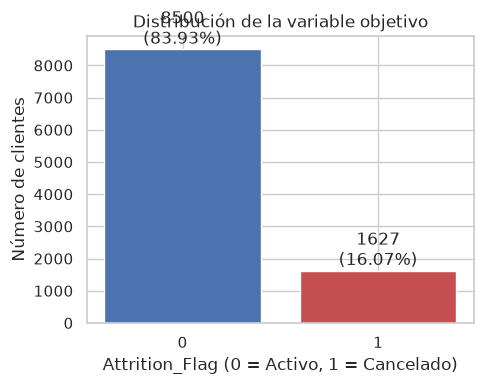

In [5]:
conteo_clases = df[COLUMNA_OBJETIVO].value_counts().sort_index()
porcentaje_clases = (conteo_clases / conteo_clases.sum() * 100).round(2)

print(conteo_clases)
print(porcentaje_clases)

fig, ax = plt.subplots(figsize=(5, 4))
colores = ["#4C72B0", "#C44E52"]
ax.bar(conteo_clases.index.astype(str), conteo_clases.values,
       color=[colores[i] for i in conteo_clases.index])
ax.set_xlabel("Attrition_Flag (0 = Activo, 1 = Cancelado)")
ax.set_ylabel("Número de clientes")
ax.set_title("Distribución de la variable objetivo")
for i, v in enumerate(conteo_clases.values):
    ax.text(i, v, f"{v}\n({porcentaje_clases.values[i]}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3. Separación de variables predictoras y variable objetivo

In [6]:
X = df.drop(columns=[COLUMNA_OBJETIVO])
y = df[COLUMNA_OBJETIVO]

print("X:", X.shape)
print("y:", y.shape)
print("\nColumnas predictoras:")
print(list(X.columns))


X: (10127, 28)
y: (10127,)

Columnas predictoras:
['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Gender_F', 'Gender_M', 'Education_Level_College', 'Education_Level_Doctorate', 'Education_Level_Graduate', 'Education_Level_High School', 'Education_Level_Post-Graduate', 'Education_Level_Uneducated', 'Education_Level_Unknown', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Income_Category_$120K +', 'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K', 'Income_Category_$80K - $120K', 'Income_Category_Less than $40K', 'Income_Category_Unknown', 'Card_Category_Blue', 'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver']


## 4. División en entrenamiento y prueba

Se usa `stratify=y` para conservar la misma proporción de clientes que cancelan en ambos conjuntos.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("\nProporción de la clase positiva en train:", round(y_train.mean(), 4))
print("Proporción de la clase positiva en test:", round(y_test.mean(), 4))


Entrenamiento: (8101, 28)
Prueba: (2026, 28)

Proporción de la clase positiva en train: 0.1607
Proporción de la clase positiva en test: 0.1604


## 5. Entrenamiento del modelo de Regresión Logística

Se utiliza `class_weight="balanced"` para compensar el desbalance de clases, de modo que el modelo no ignore a los clientes que cancelan por ser minoría.

In [8]:
modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

modelo.fit(X_train, y_train)
print("Modelo entrenado.")


Modelo entrenado.


## 6. Evaluación del modelo

In [9]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1-score: ", round(f1_score(y_test, y_pred), 4))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=["Activo (0)", "Cancelado (1)"]))


Accuracy:  0.8031
Precision: 0.4393
Recall:    0.8246
F1-score:  0.5733

Reporte de clasificación:

               precision    recall  f1-score   support

   Activo (0)       0.96      0.80      0.87      1701
Cancelado (1)       0.44      0.82      0.57       325

     accuracy                           0.80      2026
    macro avg       0.70      0.81      0.72      2026
 weighted avg       0.88      0.80      0.82      2026



### 6.1 Matriz de confusión

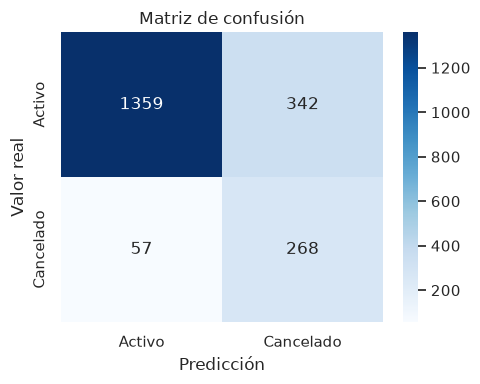

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Activo", "Cancelado"],
            yticklabels=["Activo", "Cancelado"], ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
ax.set_title("Matriz de confusión")
plt.tight_layout()
plt.show()


### 6.2 Curva ROC

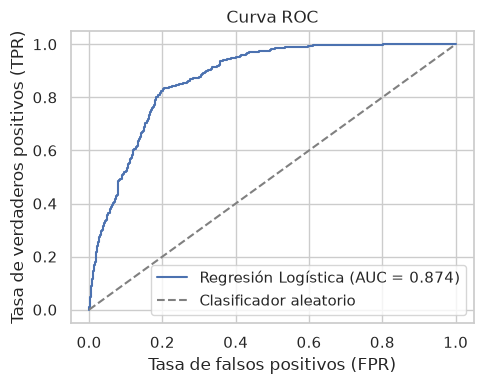

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})", color="#4C72B0")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("Curva ROC")
ax.legend()
plt.tight_layout()
plt.show()


### 6.3 Curva Precision-Recall

Especialmente útil cuando la clase positiva está desbalanceada, como en este caso.

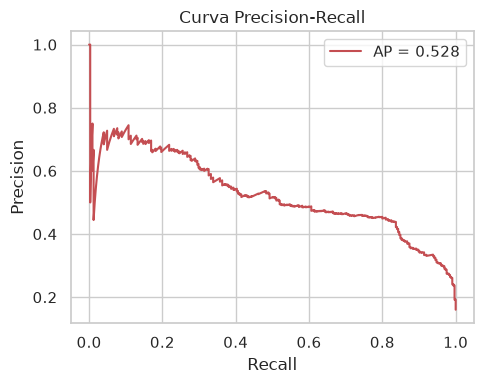

In [12]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(recall_vals, precision_vals, color="#C44E52", label=f"AP = {ap:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall")
ax.legend()
plt.tight_layout()
plt.show()


### 6.4 Importancia de variables (coeficientes del modelo)

Como las variables numéricas ya están estandarizadas, los coeficientes son comparables entre sí: un valor positivo aumenta la probabilidad de cancelación y uno negativo la reduce.

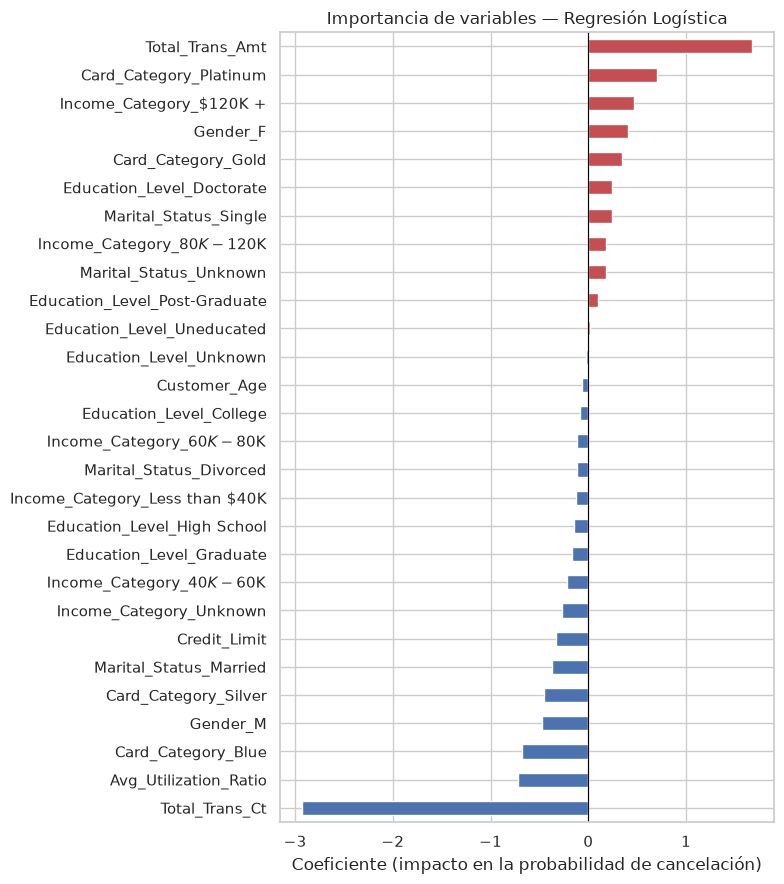

In [13]:
coeficientes = pd.Series(modelo.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colores_coef = np.where(coeficientes.values > 0, "#C44E52", "#4C72B0")
coeficientes.plot(kind="barh", ax=ax, color=colores_coef)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (impacto en la probabilidad de cancelación)")
ax.set_title("Importancia de variables — Regresión Logística")
plt.tight_layout()
plt.show()


### 6.5 Resultado en porcentaje (probabilidad de cancelación)

`modelo.predict()` devuelve la clase dura (0 o 1). Para el área comercial es más útil un **score de riesgo en porcentaje**, que se obtiene con `modelo.predict_proba()`: esta función devuelve la probabilidad de cada clase, y tomamos la de la clase 1 (cancelación).

In [14]:
probabilidad_cancelacion = modelo.predict_proba(X_test)[:, 1] * 100

resultados = pd.DataFrame({
    "Probabilidad_Cancelacion_%": probabilidad_cancelacion.round(2),
    "Prediccion": np.where(probabilidad_cancelacion >= 50, "Cancelado", "Activo")
}, index=X_test.index)

resultados.sort_values("Probabilidad_Cancelacion_%", ascending=False).head(10)


,Probabilidad_Cancelacion_%,Prediccion
8120,98.57,Cancelado
1082,97.72,Cancelado
649,97.52,Cancelado
6244,97.47,Cancelado
266,97.45,Cancelado
1043,97.39,Cancelado
544,97.02,Cancelado
886,97.00,Cancelado
425,96.97,Cancelado
568,96.75,Cancelado


**Nota:** el umbral de 50% usado arriba es el que aplica `predict()` por defecto. Si el objetivo es detectar más clientes en riesgo para la campaña de retención (aunque haya más falsos positivos), puedes bajar el umbral, por ejemplo a 30%:

```python
resultados["Prediccion_umbral_30"] = np.where(probabilidad_cancelacion >= 30, "Cancelado", "Activo")
```

## 7. Guardado del modelo entrenado

Se guarda el modelo junto con el orden de las columnas usadas en el entrenamiento, para asegurar que futuras predicciones usen exactamente las mismas variables.

In [15]:
NOMBRE_ARCHIVO_MODELO = "modelo_regresion_logistica_churn.pkl"

joblib.dump(
    {
        "modelo": modelo,
        "columnas": list(X.columns),
        "clase_positiva": 1,
        "descripcion": "Regresion Logistica - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)"
    },
    NOMBRE_ARCHIVO_MODELO
)

print(f"Modelo guardado en: {NOMBRE_ARCHIVO_MODELO}")


Modelo guardado en: modelo_regresion_logistica_churn.pkl


In [18]:
# Verificación de que el modelo guardado se puede recargar y usar
objeto_cargado = joblib.load(NOMBRE_ARCHIVO_MODELO)
modelo_recargado = objeto_cargado["modelo"]

pred_prueba = modelo_recargado.predict(X_test.iloc[:5])
print("Predicciones de prueba tras recargar el modelo:", pred_prueba)
pred_prueba = modelo_recargado.predict_proba(X_test.iloc[:5])[:, 1]
print("Probabilidades de prueba del modelo:", pred_prueba)


Predicciones de prueba tras recargar el modelo: [0 1 1 0 0]
Probabilidades de prueba del modelo: [0.03574975 0.59721016 0.78638985 0.05075179 0.09406211]
